# Python and Data Analysis on the Titanic Dataset

Completed solutions to all 10 questions in **Python_Data_Analysis_Titanic.docx**, using Python, Pandas, NumPy, Matplotlib and Seaborn.

## How to run
Place this notebook and `titanic.csv` in the same folder. Install dependencies with `pip install pandas numpy matplotlib seaborn jupyter`, open the notebook in Jupyter or VS Code, then select **Run All**. Saved outputs can also be viewed directly on GitHub.

The assignment demonstrates `sns.load_dataset("titanic")`. This notebook uses the supplied CSV copy of that dataset so no network connection is required. CSV loading may give text columns `object` types where Seaborn's loader supplies categorical types.

Missing ages are excluded from age summaries and the histogram, rather than replaced with invented values. All passenger rows are retained.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
dataset_path = Path("titanic.csv")
if not dataset_path.exists():
    raise FileNotFoundError("Place titanic.csv in the same folder as this notebook.")
df = pd.read_csv(dataset_path)
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1. Display the first 10 records
`head(10)` returns the first ten passenger records.

In [2]:
display(df.head(10))

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## 2. Find the number of rows and columns
The DataFrame `shape` returns (rows, columns).

In [3]:
rows, columns = df.shape
print(f"Rows: {rows:,}")
print(f"Columns: {columns}")

Rows: 891
Columns: 15


## 3. Display the data types of all variables
Integer and floating-point columns hold numbers, Boolean columns hold True/False, and object columns contain text in this CSV.

In [4]:
display(df.dtypes.astype(str).rename("Data type").to_frame())

,Data type
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


## 4. Identify missing values in each column
`isna()` detects missing entries and `sum()` counts them column by column.

In [5]:
missing_values = df.isna().sum().rename("Missing values").to_frame()
missing_values["Missing (%)"] = (df.isna().mean() * 100).round(2)
display(missing_values)

,Missing values,Missing (%)
survived,0,0.00
pclass,0,0.00
sex,0,0.00
age,177,19.87
sibsp,0,0.00
parch,0,0.00
fare,0,0.00
embarked,2,0.22
class,0,0.00
who,0,0.00


**Answer:** Age has 177 missing entries, deck has 688, and embarked and embark_town each have 2. All remaining columns are complete. Deck has substantial missingness; no rows are dropped for this assignment.

## 5. Find the mean age of passengers
NumPy `nanmean` ignores missing values. The mean therefore describes passengers with recorded ages.

In [6]:
mean_age = np.nanmean(df["age"].to_numpy())
print(f"Mean age: {mean_age:.2f} years")
print(f"Recorded ages: {df["age"].count()} of {len(df)} passengers")

Mean age: 29.70 years
Recorded ages: 714 of 891 passengers


**Answer:** The mean recorded age is **29.70 years**, based on **714** passengers.

## 6. Find the number of male and female passengers

In [7]:
gender_counts = df["sex"].value_counts().reindex(["male", "female"])
display(gender_counts.rename("Passengers").to_frame())

,Passengers
sex,
male,577
female,314


**Answer:** There are **577 male** and **314 female** passengers.

## 7. Calculate the survival rate
Survived is coded as 1 for survival and 0 otherwise. Its mean equals the fraction of passengers who survived.

**Survival rate = number of survivors / number of passengers × 100.**

In [8]:
survivors = int(df["survived"].sum())
survival_rate = df["survived"].mean() * 100
print(f"Survivors: {survivors} / {len(df)}")
print(f"Did not survive: {len(df) - survivors}")
print(f"Survival rate: {survival_rate:.2f}%")

Survivors: 342 / 891
Did not survive: 549
Survival rate: 38.38%


**Answer:** **342 of 891 passengers survived**, giving a survival rate of **38.38%**.

## 8. Create a bar chart showing survival by gender
The table shows counts and rates. The chart compares the percentage surviving within each gender, accounting for different group sizes.

,Passengers,Survivors,Survival rate (%)
sex,,,
female,314,233,74.20
male,577,109,18.89


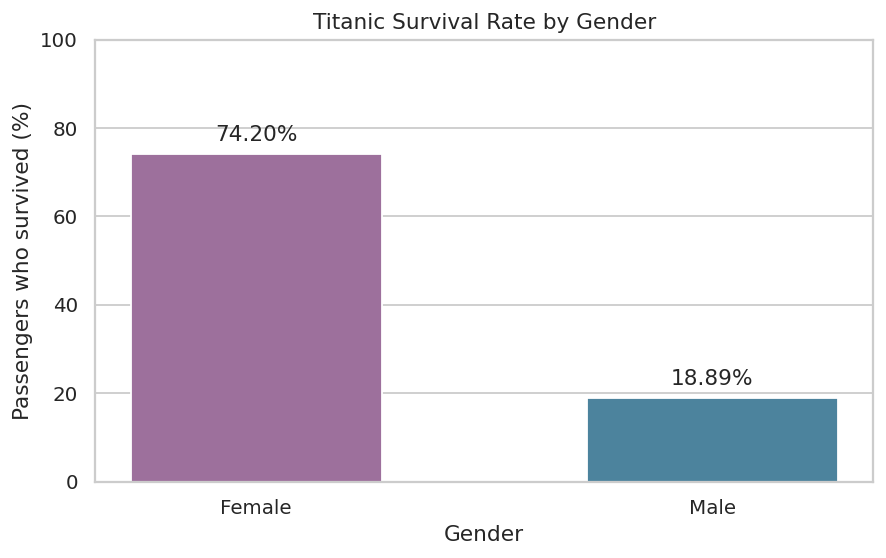

In [9]:
gender_survival = df.groupby("sex")["survived"].agg(Passengers="count", Survivors="sum")
gender_survival["Survival rate (%)"] = 100 * gender_survival["Survivors"] / gender_survival["Passengers"]
display(gender_survival.round(2))
fig, ax = plt.subplots(figsize=(7, 4.5))
rates = gender_survival["Survival rate (%)"]
bars = ax.bar(rates.index.str.title(), rates.values, color=["#9D709C", "#4C839D"], width=0.55)
ax.bar_label(bars, labels=[f"{x:.2f}%" for x in rates], padding=5)
ax.set(title="Titanic Survival Rate by Gender", xlabel="Gender", ylabel="Passengers who survived (%)", ylim=(0, 100))
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

**Interpretation:** Female passengers had a survival rate of **74.20%**, compared with **18.89%** for male passengers. This is an observed association in the supplied dataset.

## 9. Create a histogram of passenger ages
Only the 714 recorded ages are plotted. Each bar counts passengers in an age interval.

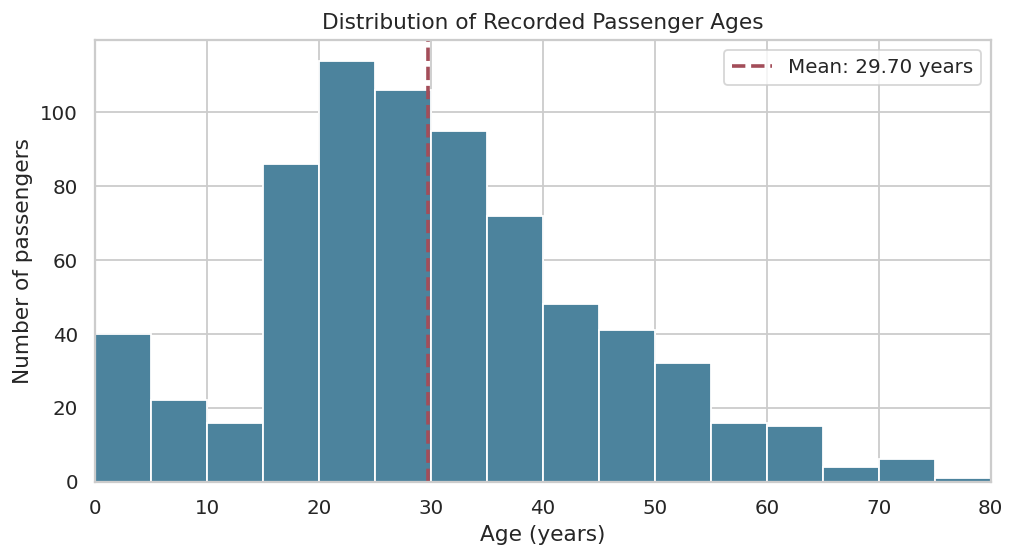

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["age"].dropna(), bins=np.arange(0, 85, 5), color="#4C839D", edgecolor="white")
ax.axvline(mean_age, color="#A34D59", linestyle="--", linewidth=2, label=f"Mean: {mean_age:.2f} years")
ax.set(title="Distribution of Recorded Passenger Ages", xlabel="Age (years)", ylabel="Number of passengers", xlim=(0, 80))
ax.legend()
fig.tight_layout()
plt.show()

**Interpretation:** Recorded ages are concentrated in young adulthood, especially the 20–40-year range. Fewer passengers have ages at the older end of the distribution. Missing ages are not represented.

## 10. Find the correlation between numerical variables
Select integer and floating-point columns and calculate Pearson correlations. Boolean flags and text columns are excluded. Pandas uses available pairs of observations, so correlations involving age exclude missing ages.

Values range from −1 to +1: the sign gives the direction of linear association and the magnitude gives its strength. Passenger class is an ordinal code (1 = first class, 3 = third class), which needs care in interpretation.

,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.338,-0.077,-0.035,0.082,0.257
pclass,-0.338,1.000,-0.369,0.083,0.018,-0.549
age,-0.077,-0.369,1.000,-0.308,-0.189,0.096
sibsp,-0.035,0.083,-0.308,1.000,0.415,0.160
parch,0.082,0.018,-0.189,0.415,1.000,0.216
fare,0.257,-0.549,0.096,0.160,0.216,1.000


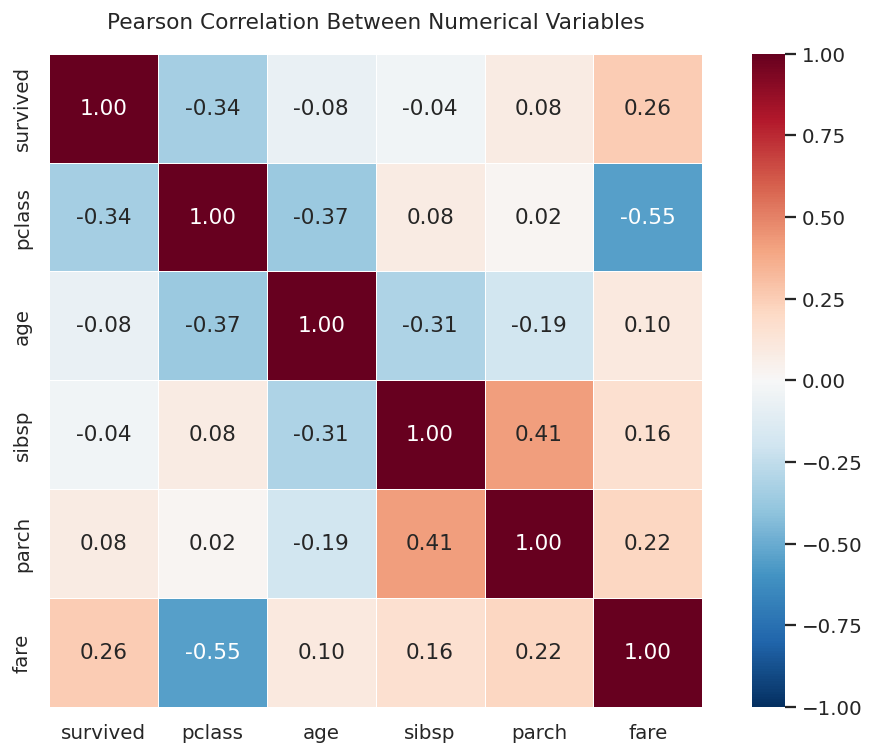

In [11]:
numerical_df = df.select_dtypes(include=[np.number])
correlation = numerical_df.corr(method="pearson")
display(correlation.round(3))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Between Numerical Variables", pad=14)
fig.tight_layout()
plt.show()

**Interpretation:**
- Survival and passenger class have a correlation of approximately **−0.338**. Higher class codes (toward third class) are associated with lower survival.
- Survival and fare have a correlation of approximately **+0.257**. Higher fares are associated with higher survival.
- Survival and age have a weak negative correlation of approximately **−0.077** among passengers with recorded ages.
- Passenger class and fare have a correlation of approximately **−0.549**, consistent with lower fares in higher-numbered classes.

Correlation alone does not establish causation, and these results describe the supplied 891 records.

## Conclusion
The dataset contains **891 rows and 15 columns**. The mean recorded age is **29.70 years** and the overall survival rate is **38.38%**. Survival differs substantially by gender and is also associated with passenger class and fare. Missing ages and the heavily incomplete deck column should be considered in further analysis.

## Upload to GitHub
Upload this `.ipynb` file and the original `titanic.csv` into the **same repository folder** using **Add file → Upload files → Commit changes**. GitHub displays the saved notebook tables and charts; run the notebook locally or in a notebook service to execute the code.